In [3]:
import pandas as pd
import numpy as np
import re
import math
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import logomaker
from scipy.stats import linregress, mannwhitneyu
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from itertools import combinations
from matplotlib.font_manager import FontProperties

# === Global style (matching Pseudo_sequencing.ipynb) ===
plt.rcParams['font.weight'] = 400
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'
plt.rcParams['legend.labelcolor'] = 'black'
plt.rcParams['pdf.fonttype'] = 42

# Cluster palette (0-indexed internally, displayed as 1-indexed)
cluster_palette = {
    0: '#7E9AB2',
    1: '#EDC264',
    2: '#F28482',
    3: '#92BEAA'
}
CLUSTER_COLOR_MAP = {
    'Cluster 1': '#7E9AB2',
    'Cluster 2': '#EDC264',
    'Cluster 3': '#F28482',
    'Cluster 4': '#92BEAA',
    'Inter-cluster': '#B8B8B8'
}

AA_list = ['A','C','D','E','F','G','H','I','K','L','M','N','P','Q','R','S','T','V','W','Y']
aa_color_dict = {
    'A':'#B8B8B8','V':'#B8B8B8','L':'#B8B8B8','I':'#B8B8B8',
    'M':'#B8B8B8','P':'#B8B8B8','G':'#B8B8B8',
    'S':'#92BEAA','T':'#92BEAA','N':'#92BEAA','Q':'#92BEAA','C':'#92BEAA',
    'K':'#7E9AB2','R':'#7E9AB2','H':'#7E9AB2',
    'D':'#F28482','E':'#F28482',
    'F':'#EDC264','W':'#EDC264','Y':'#EDC264'
}

In [4]:
# === Load data ===
mhc_dist_raw = pd.read_csv('../data/MHCcluster/heatmap_matrix.mat', sep='\t', index_col=0)
mms_vectors   = pd.read_csv('../data/MHCflurry_training.csv', index_col=0)
clusters_df   = pd.read_csv('../results/clustering_resC4.csv', index_col=0)
mms_clusters  = clusters_df.set_index('HLA')['cluster']
flurry        = pd.read_csv('../data/MHCflurry_filtered.csv')
flurry['len'] = flurry['peptide'].str.len()

# === Normalize allele names ===
# MHCCluster: HLA-A01:01 → MMS: HLA-A*01:01
def mhc_to_mms(name):
    return re.sub(r'(HLA-[ABC])(\d)', r'\1*\2', name)

mhc_dist_raw.index   = [mhc_to_mms(x) for x in mhc_dist_raw.index]
mhc_dist_raw.columns = [mhc_to_mms(x) for x in mhc_dist_raw.columns]

# Align to common 107 alleles
common = sorted(set(mhc_dist_raw.index) & set(mms_vectors.index) & set(mms_clusters.index))
print(f'Common alleles: {len(common)}')

mhc_dist    = mhc_dist_raw.loc[common, common]
mms_vectors = mms_vectors.loc[common]
mms_clusters= mms_clusters.loc[common]

# MHCCluster similarity = 1 - distance (so higher = more similar, matching BLOSUM direction)
mhc_sim = 1 - mhc_dist

Common alleles: 107


In [5]:
# === Compute pairwise similarities for scatter ===
cos_sim_sq = cosine_similarity(mms_vectors.values)

n = len(common)
cluster_arr = mms_clusters.values
results = []
for i in range(n):
    for j in range(i + 1, n):
        c1, c2 = cluster_arr[i], cluster_arr[j]
        if c1 == c2:
            pair_label = f'Cluster {c1 + 1}'
        else:
            pair_label = 'Inter-cluster'
        results.append({
            'HLA1': common[i],
            'HLA2': common[j],
            'MHCCluster_sim': mhc_sim.values[i, j],
            'MMS_cosine':     cos_sim_sq[i, j],
            'ClusterPair':    pair_label
        })

df_sim = pd.DataFrame(results)
print(f'Total pairs: {len(df_sim)}')
print(df_sim['ClusterPair'].value_counts())

Total pairs: 5671
ClusterPair
Inter-cluster    3884
Cluster 2         903
Cluster 1         703
Cluster 3         153
Cluster 4          28
Name: count, dtype: int64


Spearman ρ = 0.284, p = 1.0e-105


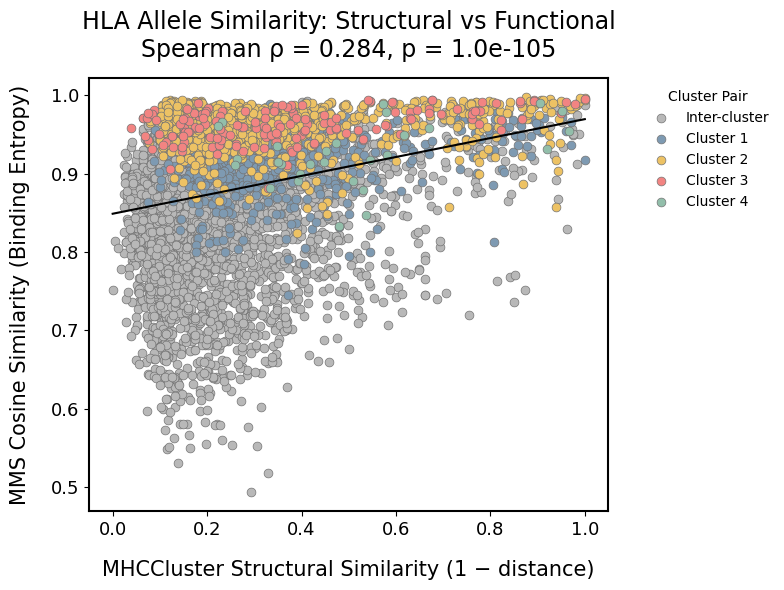

In [6]:
# === Panel A: Scatter — MHCCluster similarity vs MMS cosine similarity ===
from scipy.stats import spearmanr
x = df_sim['MHCCluster_sim']
y = df_sim['MMS_cosine']
slope, intercept, r_value, _, _ = linregress(x, y)
rho, p_value = spearmanr(x, y)
print(f'Spearman ρ = {rho:.3f}, p = {p_value:.1e}')

fig, ax = plt.subplots(figsize=(8, 6), facecolor='none')
ax.set_facecolor('none')
ax.grid(False)

# Inter-cluster first (gray, background layer)
inter = df_sim[df_sim['ClusterPair'] == 'Inter-cluster']
ax.scatter(
    inter['MHCCluster_sim'], inter['MMS_cosine'],
    label='Inter-cluster', color=CLUSTER_COLOR_MAP['Inter-cluster'],
    s=40, edgecolors='#747474', linewidth=0.5, alpha=1, zorder=1
)

# Intra-cluster (colored, foreground)
for label in sorted([c for c in df_sim['ClusterPair'].unique() if c != 'Inter-cluster']):
    sub = df_sim[df_sim['ClusterPair'] == label]
    ax.scatter(
        sub['MHCCluster_sim'], sub['MMS_cosine'],
        label=label, color=CLUSTER_COLOR_MAP.get(label, '#AAAAAA'),
        s=40, edgecolors='#747474', linewidth=0.5, alpha=1, zorder=2
    )

# Regression line
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, slope * x_line + intercept, color='black', linewidth=1.5, zorder=3)

ax.set_xlabel('MHCCluster Structural Similarity (1 − distance)', fontsize=15, labelpad=15)
ax.set_ylabel('MMS Cosine Similarity (Binding Entropy)', fontsize=15, labelpad=15)
ax.set_title(
    f'HLA Allele Similarity: Structural vs Functional\nSpearman ρ = {rho:.3f}, p = {p_value:.1e}',
    fontsize=17, pad=15
)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')
    spine.set_visible(True)
ax.tick_params(axis='both', labelsize=13)

bold_font = FontProperties(weight='regular')
ax.legend(
    title='Cluster Pair', fontsize=12,
    title_fontproperties=bold_font, prop={'weight': 'regular'},
    loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False
)

plt.tight_layout()
plt.savefig('figures/pdf/MHCcluster_vs_MMS_scatter.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig('figures/MHCcluster_vs_MMS_scatter.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

Silhouette (MMS space):        0.278
Silhouette (MHCCluster space): 0.076
→ MMS clusters are functionally cohesive but structurally diverse (complementary information)


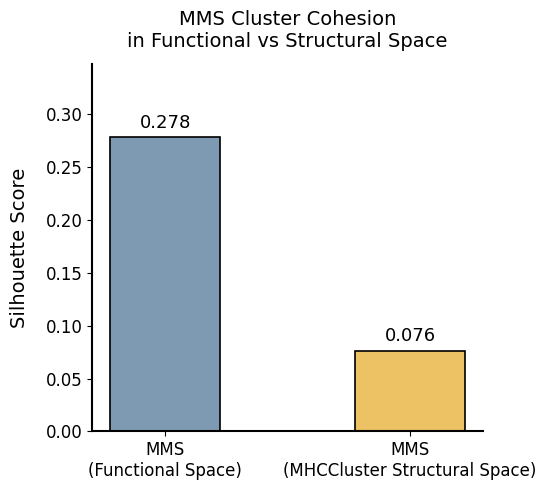

In [7]:
# === Panel B: Silhouette scores — MMS space vs MHCCluster space ===
# MMS silhouette: how cohesive are MMS clusters in their own functional space
sil_mms = silhouette_score(mms_vectors.values, mms_clusters.values)
# MHCCluster silhouette: how cohesive are MMS clusters in MHCCluster structural space
sil_mhc = silhouette_score(mhc_dist.values, mms_clusters.values, metric='precomputed')

print(f'Silhouette (MMS space):        {sil_mms:.3f}')
print(f'Silhouette (MHCCluster space): {sil_mhc:.3f}')
print('→ MMS clusters are functionally cohesive but structurally diverse (complementary information)')

methods = ['MMS\n(Functional Space)', 'MMS\n(MHCCluster Structural Space)']
scores  = [sil_mms, sil_mhc]
colors  = ['#7E9AB2', '#EDC264']

fig, ax = plt.subplots(figsize=(5.5, 5), facecolor='none')
ax.set_facecolor('none')
ax.grid(False)

bars = ax.bar(methods, scores, color=colors, width=0.45,
              edgecolor='black', linewidth=1.2)

# Value labels on bars
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.005, f'{val:.3f}',
            ha='center', va='bottom', fontsize=13, fontweight='regular')

ax.set_ylabel('Silhouette Score', fontsize=14, labelpad=12)
ax.set_title('MMS Cluster Cohesion\nin Functional vs Structural Space', fontsize=14, pad=12)
ax.set_ylim(0, max(scores) * 1.25)
ax.tick_params(axis='both', labelsize=12)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('figures/pdf/silhouette_comparison.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig('figures/silhouette_comparison.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

Intra mean: 0.646 | Inter mean: 0.767
Mann-Whitney U (intra < inter): p = 8.29e-122


/tmp/ipykernel_510984/1687515201.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


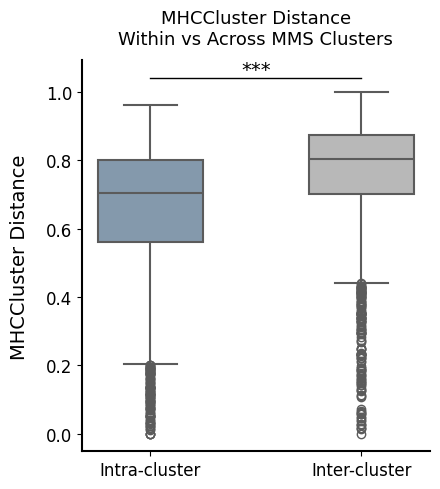

In [8]:
# === Panel C: MHCCluster distance — intra vs inter MMS cluster pairs ===
pair_records = []
for i in range(n):
    for j in range(i + 1, n):
        c1, c2 = cluster_arr[i], cluster_arr[j]
        pair_type = 'Intra-cluster' if c1 == c2 else 'Inter-cluster'
        pair_records.append({'dist': mhc_dist.values[i, j], 'type': pair_type})

pair_df = pd.DataFrame(pair_records)
intra = pair_df[pair_df['type'] == 'Intra-cluster']['dist']
inter = pair_df[pair_df['type'] == 'Inter-cluster']['dist']
stat, p_mw = mannwhitneyu(intra, inter, alternative='less')
print(f'Intra mean: {intra.mean():.3f} | Inter mean: {inter.mean():.3f}')
print(f'Mann-Whitney U (intra < inter): p = {p_mw:.2e}')

fig, ax = plt.subplots(figsize=(4.5, 5), facecolor='none')
ax.set_facecolor('none')
ax.grid(False)

sns.boxplot(
    data=pair_df, x='type', y='dist',
    order=['Intra-cluster', 'Inter-cluster'],
    palette={'Intra-cluster': '#7E9AB2', 'Inter-cluster': '#B8B8B8'},
    width=0.5, linewidth=1.5, ax=ax
)

# Significance bracket
y_max = pair_df['dist'].max()
y_bar = y_max * 1.04
ax.plot([0, 1], [y_bar, y_bar], color='black', linewidth=1)
sig = '***' if p_mw < 0.001 else ('**' if p_mw < 0.01 else ('*' if p_mw < 0.05 else 'ns'))
ax.text(0.5, y_bar + y_max * 0.01, sig, ha='center', fontsize=14)

ax.set_xlabel('', fontsize=13)
ax.set_ylabel('MHCCluster Distance', fontsize=14, labelpad=12)
ax.set_title('MHCCluster Distance\nWithin vs Across MMS Clusters', fontsize=13, pad=12)
ax.tick_params(axis='both', labelsize=12)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('figures/pdf/MHCcluster_intra_inter_boxplot.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig('figures/MHCcluster_intra_inter_boxplot.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [9]:
# === Find divergent pairs for Panel D ===
# Alleles that MHCCluster considers structurally identical (dist≈0) but MMS places in different clusters
divergent = []
for i in range(n):
    for j in range(i + 1, n):
        if cluster_arr[i] == cluster_arr[j]:
            continue
        divergent.append({
            'allele1': common[i], 'allele2': common[j],
            'cluster1': cluster_arr[i], 'cluster2': cluster_arr[j],
            'mhc_dist': mhc_dist.values[i, j],
            'mms_cosine': cos_sim_sq[i, j]
        })

div_df = pd.DataFrame(divergent).sort_values('mhc_dist')
print('Top structurally similar / functionally divergent pairs:')
print(div_df.head(10).to_string(index=False))

Top structurally similar / functionally divergent pairs:
    allele1     allele2  cluster1  cluster2  mhc_dist  mms_cosine
HLA-C*03:03 HLA-C*03:04         2         0     0.000    0.987960
HLA-A*24:02 HLA-A*24:07         1         0     0.012    0.951068
HLA-A*24:02 HLA-A*24:13         1         0     0.017    0.912332
HLA-A*23:01 HLA-A*24:02         0         1     0.017    0.975117
HLA-B*35:07 HLA-B*35:08         1         0     0.025    0.950939
HLA-B*35:01 HLA-B*35:08         1         0     0.025    0.948951
HLA-A*02:01 HLA-A*02:11         1         0     0.027    0.957326
HLA-C*06:02 HLA-C*07:01         0         1     0.037    0.829174
HLA-B*51:01 HLA-B*51:08         0         1     0.040    0.981550
HLA-A*02:04 HLA-A*02:07         0         3     0.046    0.934643


Unmapped terminals: 0


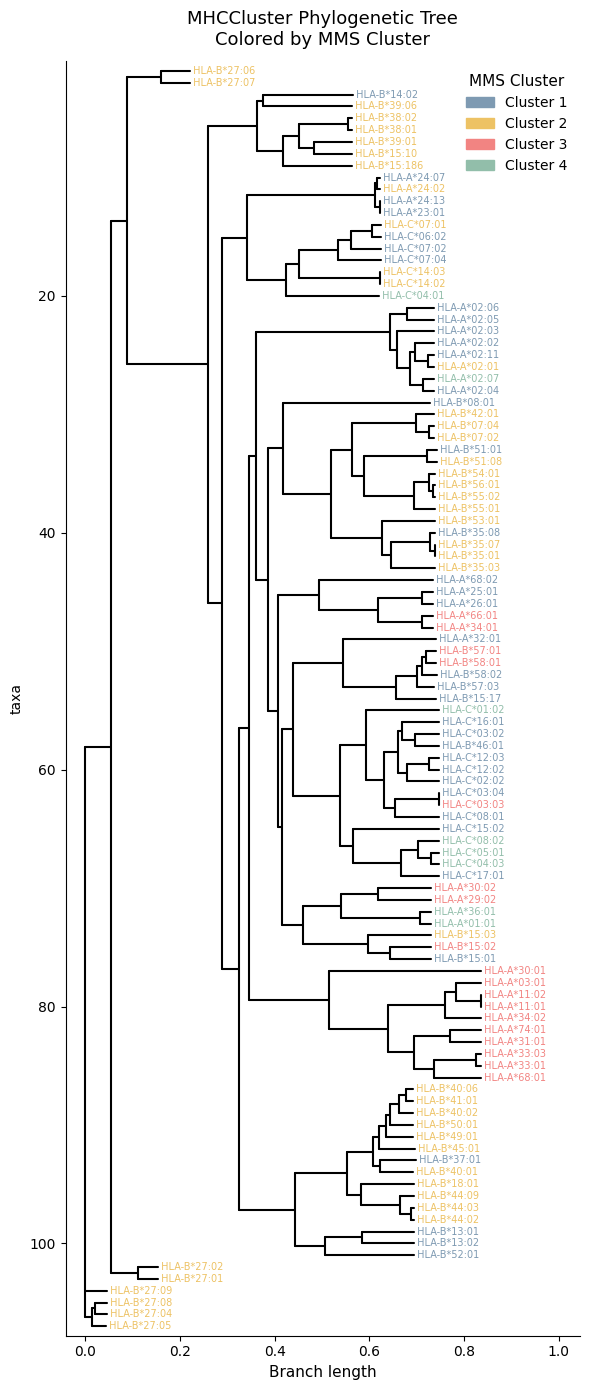

In [11]:
# === Tree: MHCCluster phylogenetic tree colored by MMS cluster ===
from Bio import Phylo

def tree_name_to_mms(name):
    """HLA-B27_06 -> HLA-B*27:06"""
    name = name.replace('_', ':')
    return re.sub(r'(HLA-[ABC])(\d)', r'\1*\2', name)

with open('../data/MHCcluster/tree.con') as f:
    newick_str = f.read().strip()

tree = Phylo.read(io.StringIO(newick_str), 'newick')

for clade in tree.get_terminals():
    clade.mms_name    = tree_name_to_mms(clade.name)
    clade.mms_cluster = mms_clusters.get(clade.mms_name, None)

unmapped = [c.name for c in tree.get_terminals() if c.mms_cluster is None]
print(f'Unmapped terminals: {len(unmapped)}')

fig, ax = plt.subplots(figsize=(6, 14), facecolor='none')
ax.set_facecolor('none')

Phylo.draw(
    tree,
    axes=ax,
    label_func=lambda c: c.mms_name if hasattr(c, 'mms_name') else c.name,
    do_show=False,
    show_confidence=False
)

# Color leaf labels by MMS cluster
for text in ax.texts:
    label = text.get_text().strip()
    cluster = mms_clusters.get(label, None)
    if cluster is not None:
        text.set_color(cluster_palette[cluster])
    text.set_fontsize(7)

ax.set_title('MHCCluster Phylogenetic Tree\nColored by MMS Cluster', fontsize=13, pad=12)
ax.set_xlabel('Branch length', fontsize=11)
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='both', labelsize=10)

legend_handles = [
    mpatches.Patch(color=cluster_palette[k], label=f'Cluster {k+1}')
    for k in sorted(cluster_palette)
]
ax.legend(handles=legend_handles, title='MMS Cluster',
          loc='upper right', fontsize=10, title_fontsize=11, frameon=False)

plt.tight_layout()
plt.savefig('figures/pdf/MHCcluster_tree_MMS_colored.pdf', dpi=300, transparent=True, bbox_inches='tight')
plt.savefig('figures/MHCcluster_tree_MMS_colored.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()